# Hodgkin-Huxley Model

Part 1 of the plan (see `../plan/00-overview.md`): implement the HH ODEs, reproduce a single action potential, and evaluate the model against known textbook values before moving on to the f-I curve.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

plt.rcParams["figure.dpi"] = 110

## Model

Standard 1952 Hodgkin-Huxley parametrization (units: mV, ms, uF/cm^2, mS/cm^2, uA/cm^2), in the modern absolute-voltage convention (resting potential -65 mV) used in most textbooks (e.g. Dayan & Abbott).

In [2]:
# Membrane / channel constants
C_M = 1.0      # uF/cm^2
G_NA, E_NA = 120.0, 50.0    # mS/cm^2, mV
G_K, E_K = 36.0, -77.0      # mS/cm^2, mV
G_L, E_L = 0.3, -54.387     # mS/cm^2, mV


def alpha_m(V):
    return 0.1 * (V + 40.0) / (1.0 - np.exp(-(V + 40.0) / 10.0))


def beta_m(V):
    return 4.0 * np.exp(-(V + 65.0) / 18.0)


def alpha_h(V):
    return 0.07 * np.exp(-(V + 65.0) / 20.0)


def beta_h(V):
    return 1.0 / (1.0 + np.exp(-(V + 35.0) / 10.0))


def alpha_n(V):
    return 0.01 * (V + 55.0) / (1.0 - np.exp(-(V + 55.0) / 10.0))


def beta_n(V):
    return 0.125 * np.exp(-(V + 65.0) / 80.0)


def steady_state(V):
    """Gating variable steady states x_inf(V), used for resting initial conditions."""
    m_inf = alpha_m(V) / (alpha_m(V) + beta_m(V))
    h_inf = alpha_h(V) / (alpha_h(V) + beta_h(V))
    n_inf = alpha_n(V) / (alpha_n(V) + beta_n(V))
    return m_inf, h_inf, n_inf

In [3]:
def ionic_currents(V, m, h, n):
    I_Na = G_NA * m**3 * h * (V - E_NA)
    I_K = G_K * n**4 * (V - E_K)
    I_L = G_L * (V - E_L)
    return I_Na, I_K, I_L


def hh_rhs(t, y, I_inj):
    """dy/dt for y = [V, m, h, n]. I_inj(t) is injected current in uA/cm^2."""
    V, m, h, n = y
    I_Na, I_K, I_L = ionic_currents(V, m, h, n)
    dV = (I_inj(t) - I_Na - I_K - I_L) / C_M
    dm = alpha_m(V) * (1 - m) - beta_m(V) * m
    dh = alpha_h(V) * (1 - h) - beta_h(V) * h
    dn = alpha_n(V) * (1 - n) - beta_n(V) * n
    return [dV, dm, dh, dn]


def step_current(amplitude, t_on, t_off):
    """Returns I_inj(t): `amplitude` uA/cm^2 between t_on and t_off, else 0."""
    def I(t):
        return amplitude if t_on <= t <= t_off else 0.0
    return I


def run_hh(I_inj, t_span=(0.0, 50.0), V0=-65.0, max_step=0.01):
    m0, h0, n0 = steady_state(V0)
    sol = solve_ivp(
        hh_rhs, t_span, [V0, m0, h0, n0], args=(I_inj,),
        max_step=max_step, dense_output=True,
    )
    return sol

## Milestone 1 — single spike, sanity-checked

Fire one spike with a suprathreshold current step, then check the result against known HH textbook values: resting potential ~-65 mV, spike peak ~+40 mV, and a refractory period after the spike.

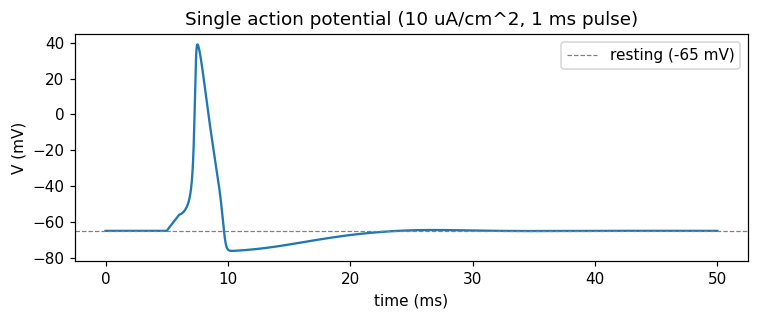

resting V (t=0):   -65.00 mV
peak V:             39.07 mV
min V post-spike:   -76.17 mV  (undershoot / refractory dip)


In [4]:
I_step = step_current(amplitude=10.0, t_on=5.0, t_off=6.0)
sol = run_hh(I_step, t_span=(0.0, 50.0))

t = sol.t
V, m, h, n = sol.y

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(t, V)
ax.axhline(-65, color="grey", lw=0.8, ls="--", label="resting (-65 mV)")
ax.set_xlabel("time (ms)")
ax.set_ylabel("V (mV)")
ax.set_title("Single action potential (10 uA/cm^2, 1 ms pulse)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"resting V (t=0):   {V[0]:.2f} mV")
print(f"peak V:             {V.max():.2f} mV")
print(f"min V post-spike:   {V[t > 6].min():.2f} mV  (undershoot / refractory dip)")

## Milestone 2 — gating variables and ionic currents

The core "why does a spike look like that" figure: V(t) alongside m/h/n and the three ionic currents, all on the same time axis.

- Na+ activation (m) is fast, driving the fast depolarizing upswing.
- Na+ inactivation (h) closes shortly after, ending the spike.
- K+ activation (n) is slower, driving repolarization and the undershoot.

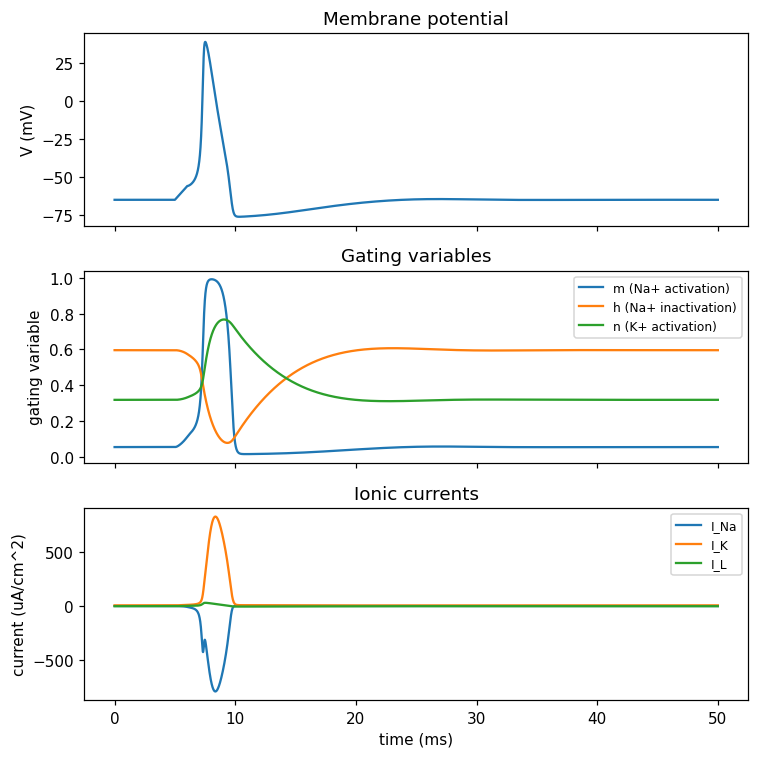

In [5]:
I_Na, I_K, I_L = ionic_currents(V, m, h, n)

fig, axes = plt.subplots(3, 1, figsize=(7, 7), sharex=True)

axes[0].plot(t, V)
axes[0].set_ylabel("V (mV)")
axes[0].set_title("Membrane potential")

axes[1].plot(t, m, label="m (Na+ activation)")
axes[1].plot(t, h, label="h (Na+ inactivation)")
axes[1].plot(t, n, label="n (K+ activation)")
axes[1].set_ylabel("gating variable")
axes[1].set_title("Gating variables")
axes[1].legend(loc="upper right", fontsize=8)

axes[2].plot(t, I_Na, label="I_Na")
axes[2].plot(t, I_K, label="I_K")
axes[2].plot(t, I_L, label="I_L")
axes[2].set_ylabel("current (uA/cm^2)")
axes[2].set_xlabel("time (ms)")
axes[2].set_title("Ionic currents")
axes[2].legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.savefig("../figures/01_spike_gating_currents.png")
plt.show()

## Milestone 3 — f-I curve

Sweep the injected current amplitude (held for a long window, not a brief pulse) and measure the resulting firing rate. HH is a well-known **class 2** excitable system: firing rate turns on at a nonzero minimum frequency at threshold (a discontinuous jump), unlike class 1 models (e.g. some reduced/integrate-and-fire neurons) where the rate rises continuously from zero. Worth checking that the curve actually shows this rather than assuming it.

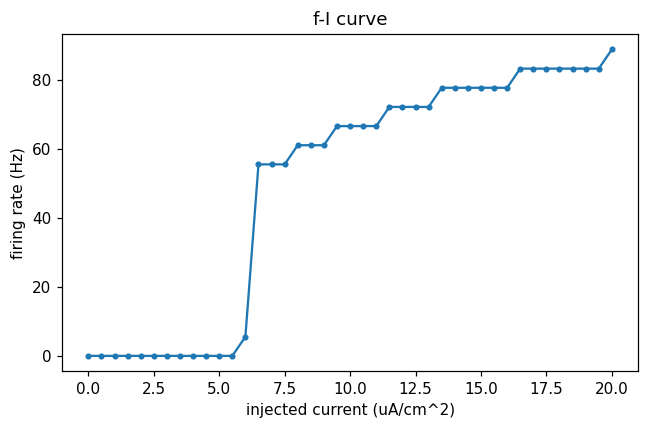

threshold current:      ~6.0 uA/cm^2
rate just below thresh:  0.0 Hz
rate just at/above:      5.6 Hz  (jump => class 2 excitability)


In [6]:
from scipy.signal import find_peaks


def firing_rate_hz(amplitude, duration=200.0, settle=20.0):
    """Constant current for `duration` ms; count spikes (V peaks > 0 mV) after
    a `settle` ms transient, convert to a rate in Hz."""
    I_const = step_current(amplitude, t_on=0.0, t_off=duration)
    sol = run_hh(I_const, t_span=(0.0, duration), max_step=0.02)
    t, V = sol.t, sol.y[0]

    mask = t > settle
    peaks, _ = find_peaks(V[mask], height=0.0, distance=int(2.0 / 0.02))
    n_spikes = len(peaks)
    window_s = (duration - settle) / 1000.0
    return n_spikes / window_s if window_s > 0 else 0.0


amplitudes = np.arange(0.0, 20.5, 0.5)
rates = [firing_rate_hz(a) for a in amplitudes]

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(amplitudes, rates, marker="o", ms=3)
ax.set_xlabel("injected current (uA/cm^2)")
ax.set_ylabel("firing rate (Hz)")
ax.set_title("f-I curve")
plt.tight_layout()
plt.savefig("../figures/02_fi_curve.png")
plt.show()

# Class 2 check: does the rate turn on discontinuously (jump to a nonzero
# minimum), rather than rising continuously from 0 Hz?
onset_idx = next(i for i, r in enumerate(rates) if r > 0)
print(f"threshold current:      ~{amplitudes[onset_idx]:.1f} uA/cm^2")
print(f"rate just below thresh:  {rates[onset_idx - 1]:.1f} Hz")
print(f"rate just at/above:      {rates[onset_idx]:.1f} Hz  (jump => class 2 excitability)")